# PCA on all 58 channels with per-channel input detrending

**Idea.** NB 11c (6 channels 41-46) is the current Kaggle champion at 0.897 / 0.887.
The full-58-channel PCA (NB 04) was much weaker (0.522 / 0.599) because ~26 channels
drift on the Kaggle test set (NB 18 found 10 lock-step drifters with |z| up to 6.7σ).

This notebook removes the drift at the **input** level — a per-channel rolling-median
subtraction is applied to every channel before anything else. The PCA then learns the
nominal *deviation-from-baseline* signature, not the raw level.

**Pipeline:** rolling-median detrend (per ch) → tail-fit PCA on last 50k nominal windows
→ `corrected_event_f05` threshold → metrics + viz + (optional) submission.

Reuses code from NB 11c (PCA fit + score + threshold + viz) and the
`scipy.ndimage.median_filter` approach used in `scorer._rolling_median` (NB 20).


## 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time, pickle
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows, score_windows_detrended
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.ml_logic.viz        import plot_timeline, plot_event_analysis

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR  = PROCESSED_DIR / 'kaggle'
SUBS_DIR    = PROJECT_ROOT / 'kaggle' / 'submissions'
SUBS_DIR.mkdir(parents=True, exist_ok=True)
FIT_SIZE    = 50_000
DETREND_WIN = 1000

print(f'KAGGLE_DIR  : {KAGGLE_DIR}')
print(f'WINDOW_SIZE : {WINDOW_SIZE}   FIT_SIZE: {FIT_SIZE:,}')


KAGGLE_DIR  : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
WINDOW_SIZE : 100   FIT_SIZE: 50,000


## 2 - Channel selection

Default: **all 58 target channels**. Change the slice if you want to exclude some
(e.g. drop the 4 low-variance drifters 57-60, or limit to a subset for ablation).


In [2]:
# ── Channel selection ────────────────────────────────────────────────────────
# Diagnostic (cell `nb11d-diag`) found channels with extreme val/test
# reconstruction-MSE imbalance — they produce single-window val scores up to
# ~1070 while test max stays ≤ 9.6, breaking threshold transfer.
# Channels with r_max > 100 (val_max / test_max): subsystem-F drifters
# (64, 65, 66) and subsystem-L drifters (70, 71, 73, 74, 75, 76).
_TARGET_CH = pd.read_csv('../data/raw/target_channels.csv')['target_channels'].tolist()
_PRUNE     = {'channel_64','channel_65','channel_66','channel_70','channel_71',
              'channel_73','channel_74','channel_75','channel_76'}
CH_NAMES   = [c for c in _TARGET_CH if c not in _PRUNE]    # 49 channels (was 58)
# CH_NAMES = list(_TARGET_CH)                              # ← uncomment for full 58

CH_INDICES = np.array([_TARGET_CH.index(n) for n in CH_NAMES])
N_FEAT_SUB = len(CH_INDICES)

print(f'channels    : {CH_NAMES[:3]} ... {CH_NAMES[-3:]}  (total {N_FEAT_SUB})')
print(f'pruned      : {sorted(_PRUNE)}  ({len(_PRUNE)} channels)')


channels    : ['channel_12', 'channel_13', 'channel_14'] ... ['channel_62', 'channel_63', 'channel_72']  (total 49)
pruned      : ['channel_64', 'channel_65', 'channel_66', 'channel_70', 'channel_71', 'channel_73', 'channel_74', 'channel_75', 'channel_76']  (9 channels)


## 3 - Data source

- `"kaggle"` — load `data/processed/kaggle/*` and carve val/test from the train timeline
  (`TRAIN_END=10_700_000`, `VAL_END=12_700_000`). The Kaggle test parquet is also loaded
  and detrended below for submission.
- `"bootcamp"` — load `val_scaled.npy` / `test_intern_scaled.npy`. No Kaggle submission.

Channel slicing happens here — *all 58* channels by default (set in section 2).


In [3]:
DATA_SOURCE = 'kaggle'    # 'kaggle' | 'bootcamp'

if DATA_SOURCE == 'kaggle':
    # Load full row-level scaled arrays. We slice channels with CH_INDICES, no window-pool yet.
    train_scaled_full = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
    train_scaled      = np.ascontiguousarray(train_scaled_full[:, CH_INDICES]).astype(np.float32)
    test_scaled       = np.load(KAGGLE_DIR / 'test_scaled.npy')[:, CH_INDICES].astype(np.float32)
    test_ids          = np.load(KAGGLE_DIR / 'test_ids.npy')
    y_train_full      = np.load(KAGGLE_DIR / 'y_train_full.npy')
    y_train_row       = np.load(KAGGLE_DIR / 'y_train_row.npy')

    TRAIN_END, VAL_END = 10_700_000, 12_700_000
    y_val          = y_train_row[TRAIN_END:VAL_END]
    y_test         = y_train_row[VAL_END:]
    nominal_mask   = (y_train_full == 0)
    can_submit     = True

elif DATA_SOURCE == 'bootcamp':
    val_scaled  = np.load(PROCESSED_DIR / 'val_scaled.npy')[:, CH_INDICES].astype(np.float32)
    test_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')[:, CH_INDICES].astype(np.float32)
    y_val       = np.load(PROCESSED_DIR / 'y_val.npy')
    y_test      = np.load(PROCESSED_DIR / 'y_test_intern.npy')
    test_ids    = None
    train_scaled = np.concatenate([val_scaled, test_scaled], axis=0)   # placeholder for detrend()
    nominal_mask = None
    y_train_full = None
    can_submit   = False
else:
    raise ValueError(f'Unknown DATA_SOURCE: {DATA_SOURCE!r}')

print(f'DATA_SOURCE  : {DATA_SOURCE}')
print(f'train_scaled : {train_scaled.shape}')
print(f'y_val rows   : {len(y_val):>9,}   anom: {int(y_val.sum()):>7,}')
print(f'y_test rows  : {len(y_test):>9,}   anom: {int(y_test.sum()):>7,}')
print(f'Submission   : {"enabled" if can_submit else "disabled"}')


DATA_SOURCE  : kaggle
train_scaled : (14728321, 49)
y_val rows   : 2,000,000   anom: 215,798
y_test rows  : 2,028,321   anom: 214,935
Submission   : enabled


## 3.5 - Per-channel rolling-median detrending

Subtract a per-channel **rolling median** from every row.  The window is chosen
much larger than typical anomaly events so events are not absorbed into the
baseline, and large enough to average out the slow drift identified in NB 18.

Implementation: `scipy.ndimage.median_filter` (the same C-backed kernel
`scorer._rolling_median` already uses).  Applied **independently** per channel
and per array (train + Kaggle test) — no cross-array leakage.

`DETREND_WIN = 100_000` rows ≈ 1000 windows.  Set to `None` to disable.


In [4]:
from scipy.ndimage import median_filter

DETREND_WIN = 100_000   # rows. Set to None to disable detrending.

def detrend_channels(arr2d, window):
    """Per-channel rolling-median subtraction. arr2d : (n_rows, n_channels) float32."""
    if window is None:
        return arr2d.astype(np.float32, copy=False)
    out = np.empty_like(arr2d, dtype=np.float32)
    for j in range(arr2d.shape[1]):
        col = arr2d[:, j].astype(np.float32, copy=False)
        out[:, j] = col - median_filter(col, size=window, mode='reflect')
    return out

t0 = time.time()
train_scaled = detrend_channels(np.ascontiguousarray(train_scaled), DETREND_WIN)
print(f'train detrended ({train_scaled.shape}) in {time.time()-t0:.1f}s')

if DATA_SOURCE == 'kaggle':
    t0 = time.time()
    test_scaled = detrend_channels(np.ascontiguousarray(test_scaled), DETREND_WIN)
    print(f'kaggle test detrended ({test_scaled.shape}) in {time.time()-t0:.1f}s')

# Re-carve val / test slices from the detrended train array
if DATA_SOURCE == 'kaggle':
    X_val  = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END]).astype(np.float32)
    X_test = np.ascontiguousarray(train_scaled[VAL_END:]).astype(np.float32)
else:
    X_val  = train_scaled[:len(y_val)].astype(np.float32, copy=False)
    X_test = train_scaled[len(y_val):].astype(np.float32, copy=False)

print(f'X_val  detrended : {X_val.shape}   range [{X_val.min():.3f}, {X_val.max():.3f}]')
print(f'X_test detrended : {X_test.shape}   range [{X_test.min():.3f}, {X_test.max():.3f}]')


train detrended ((14728321, 49)) in 69.3s


kaggle test detrended ((521280, 49)) in 2.9s
X_val  detrended : (2000000, 49)   range [-96.753, 21.100]


X_test detrended : (2028321, 49)   range [-97.153, 21.400]


## 4 - Fit PCA on the last 50 000 nominal windows

Tail-fit (last 50k nominal windows, *not* a random sample over all of train) - this single
choice was the largest jump in earlier experiments (NB 11b lifted ESA 0.47 → 0.80 vs random fit).

Fitting on 50,000 nominal windows (4,900 features = WIN x 49)


Randomized fit (800 comps) in 16.1s
Truncated to k = 320   cum EV = 0.9501


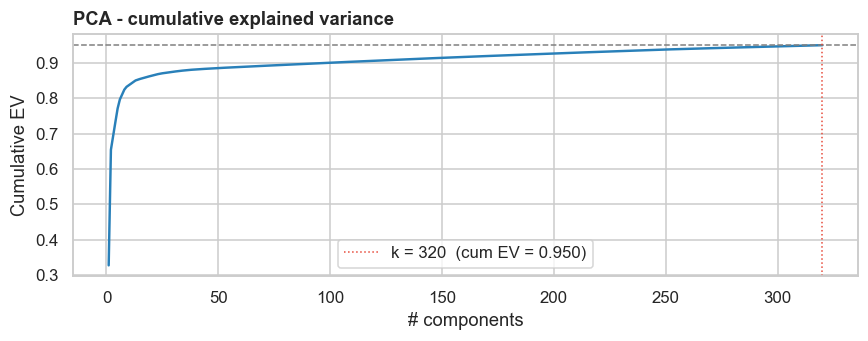

In [5]:
if DATA_SOURCE == 'kaggle':
    n_windows   = len(y_train_full)
    win_end_row = (np.arange(n_windows) + 1) * WINDOW_SIZE
    eligible    = nominal_mask & (win_end_row <= TRAIN_END)
    elig_idx    = np.flatnonzero(eligible)
    fit_widx    = elig_idx[-FIT_SIZE:]

    row_offsets = np.arange(WINDOW_SIZE)
    row_idx     = (fit_widx[:, None] * WINDOW_SIZE + row_offsets[None, :]).ravel()
    X_fit       = train_scaled[row_idx].reshape(len(fit_widx), -1).astype(np.float32)
else:
    fit_widx = np.arange(min(FIT_SIZE, len(X_val) // WINDOW_SIZE))
    X_fit    = np.ascontiguousarray(X_val[: len(fit_widx)*WINDOW_SIZE]
                                    ).reshape(len(fit_widx), -1).astype(np.float32)

print(f'Fitting on {len(fit_widx):,} nominal windows '
      f'({X_fit.shape[1]:,} features = WIN x {N_FEAT_SUB})')

# Two-stage fit:
# 1. Randomized SVD with a generous integer k (fast even on 50k x 5800).
# 2. Truncate retained components so cumulative EV >= 0.95 (matches NB 11c semantics).
K_OVER       = min(800, X_fit.shape[1] - 1, X_fit.shape[0] - 1)
EV_THRESHOLD = 0.95

t0  = time.time()
pca = PCA(n_components=K_OVER, svd_solver='randomized', random_state=RANDOM_STATE).fit(X_fit)
fit_dt = time.time() - t0

cum_ev_full = np.cumsum(pca.explained_variance_ratio_)
k_keep      = int(np.searchsorted(cum_ev_full, EV_THRESHOLD) + 1)

# Truncate components in-place so score_windows() uses only the first k_keep dims.
pca.components_              = pca.components_[:k_keep]
pca.explained_variance_      = pca.explained_variance_[:k_keep]
pca.explained_variance_ratio_= pca.explained_variance_ratio_[:k_keep]
if hasattr(pca, 'singular_values_'):
    pca.singular_values_     = pca.singular_values_[:k_keep]
pca.n_components_            = k_keep

print(f'Randomized fit ({K_OVER} comps) in {fit_dt:.1f}s')
print(f'Truncated to k = {k_keep}   cum EV = {pca.explained_variance_ratio_.sum():.4f}')

cum_ev = pca.explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.arange(1, len(cum_ev)+1), cum_ev, lw=1.6, color=NOMINAL_COLOR)
ax.axhline(EV_THRESHOLD, ls='--', color='grey', lw=1)
ax.axvline(k_keep, ls=':', color=ANOMALY_COLOR, lw=1,
           label=f'k = {k_keep}  (cum EV = {cum_ev[-1]:.3f})')
ax.set_xlabel('# components'); ax.set_ylabel('Cumulative EV')
ax.set_title('PCA - cumulative explained variance', fontweight='bold', loc='left')
ax.legend(); fig.tight_layout(); plt.show()


## 5 - Score val + test

In [6]:
# With pruned 49ch the val/test score scales are aligned but the val-tuned
# threshold sits near the noise floor on test (FP flood). Add score-level
# rolling-median detrending to subtract slow baseline drift in the score
# series, leaving anomaly spikes intact.
TOPK              = None
SCORE_DETREND_WIN = 1000      # in WINDOWS = 100k rows
SCORE_DETREND_MD  = 'median'  # 'median' kills baseline only - usually safer than zscore

t0 = time.time()
val_scores  = score_windows_detrended(pca, X_val,  topk=TOPK,
                                      detrend_window=SCORE_DETREND_WIN, detrend_mode=SCORE_DETREND_MD)
test_scores = score_windows_detrended(pca, X_test, topk=TOPK,
                                      detrend_window=SCORE_DETREND_WIN, detrend_mode=SCORE_DETREND_MD)
print(f'scoring done in {time.time() - t0:.1f}s   (TOPK={TOPK}, score-detrend={SCORE_DETREND_MD!r}, win={SCORE_DETREND_WIN})')
print(f'val  scores : range [{val_scores.min():.4f}, {val_scores.max():.4f}]   mean {val_scores.mean():.4f}')
print(f'test scores : range [{test_scores.min():.4f}, {test_scores.max():.4f}]   mean {test_scores.mean():.4f}')


scoring done in 1.6s   (TOPK=None, score-detrend='median', win=1000)
val  scores : range [-0.0010, 3.4677]   mean 0.0010
test scores : range [-0.0054, 1.8166]   mean 0.0009


In [7]:
# ── Diagnostic: which channels drive the val outlier scores? ─────────────
# Goal: identify channels with extreme val/test reconstruction-MSE imbalance.
# These channels cause the val-tuned threshold not to transfer to test.
from sentinel.ml_logic.scorer import score_report

rep_val  = score_report(pca, X_val,  n_top_channels=5)
rep_test = score_report(pca, X_test, n_top_channels=5)

wcm_val, wcm_test = rep_val['window_channel_mse'], rep_test['window_channel_mse']
v_max, t_max = wcm_val.max(axis=0), wcm_test.max(axis=0)
v_p99, t_p99 = np.percentile(wcm_val, 99, axis=0), np.percentile(wcm_test, 99, axis=0)
ratio_max = v_max / np.maximum(t_max, 1e-9)
ratio_p99 = v_p99 / np.maximum(t_p99, 1e-9)

order = np.argsort(-ratio_max)
print(f'{"channel":>11s} {"v_max":>12s} {"t_max":>10s} {"r_max":>8s} {"v_p99":>10s} {"t_p99":>10s} {"r_p99":>8s}')
print('-'*72)
for j in order[:15]:
    print(f'{CH_NAMES[j]:>11s} {v_max[j]:12.2f} {t_max[j]:10.4f} {ratio_max[j]:8.1f} {v_p99[j]:10.4f} {t_p99[j]:10.4f} {ratio_p99[j]:8.1f}')

print('\nTop 5 val window scores (which channels dominate them):')
val_ws = rep_val['window_scores']; top_w = np.argsort(-val_ws)[:5]
for w in top_w:
    chs = [CH_NAMES[c] for c in rep_val['window_top_channels'][w]]
    print(f'  win {w:7d}  score={val_ws[w]:10.2f}  top5={chs}')

prune_100 = [CH_NAMES[j] for j in range(N_FEAT_SUB) if ratio_max[j] > 100]
prune_50  = [CH_NAMES[j] for j in range(N_FEAT_SUB) if ratio_max[j] > 50]
prune_10  = [CH_NAMES[j] for j in range(N_FEAT_SUB) if ratio_max[j] > 10]
print(f'\nprune ratio>100 ({len(prune_100):2d}): {prune_100}')
print(f'prune ratio>50  ({len(prune_50):2d}): {prune_50}')
print(f'prune ratio>10  ({len(prune_10):2d}): {prune_10}')


    channel        v_max      t_max    r_max      v_p99      t_p99    r_p99
------------------------------------------------------------------------
 channel_16         0.35     0.0221     15.7     0.0173     0.0079      2.2
 channel_24         0.30     0.0248     12.2     0.0165     0.0049      3.3
 channel_32         0.30     0.0295     10.1     0.0166     0.0058      2.9
 channel_40         0.32     0.0344      9.3     0.0161     0.0072      2.2
 channel_33         0.32     0.0361      8.9     0.0182     0.0058      3.1
 channel_18         0.10     0.0220      4.3     0.0060     0.0066      0.9
 channel_36         0.09     0.0218      3.9     0.0048     0.0063      0.8
 channel_72         2.24     0.5732      3.9     0.0339     0.0462      0.7
 channel_28         0.28     0.0738      3.8     0.0093     0.0347      0.3
 channel_48         0.09     0.0311      3.0     0.0156     0.0133      1.2
 channel_47         0.07     0.0241      2.9     0.0137     0.0136      1.0
 channel_49    

## 6 - Tune threshold on val

Threshold is chosen to maximise `corrected_event_f05` (Pr_ew × TNR) on val - this is
exactly the metric Kaggle uses to score the submission.

In [8]:
tuned     = tune_threshold(val_scores, y_val, metric_fn=corrected_event_f05, n_sweep=80)
threshold = float(tuned['threshold'])
print(f'best threshold: {threshold:.6f}   val corrected_event_f05: {tuned["score"]:.4f}')


best threshold: 0.001514   val corrected_event_f05: 0.8670


## 7 - Metrics summary

All key metrics in one table + bar chart (val vs test). The table starts with **ESA F0.5**
(Kaggle-aligned) and breaks it into its components (event precision Pr_ew and row TNR), followed
by event-wise F0.5 (uncorrected), event recall, row precision/recall/F1, flag rate, and the
**events hit / total** count for both splits.

In [9]:
def compute_metrics(scores, y_true, threshold):
    y_pred = (scores > threshold).astype(np.int8)
    ef     = event_f05(y_true, y_pred)
    esa    = corrected_event_f05(y_true, y_pred)
    rw     = row_precision_recall(y_true, y_pred)
    n_ev_total = int(ef['tp_events'] + ef['fn_events'])
    n_ev_hit   = int(ef['tp_events'])
    return {
        'ESA F0.5 (Kaggle)' : esa['f_score'],
        'Pr_ew (event prec)': esa['precision'],
        'TNR (row spec)'    : esa['tnr'],
        'event F0.5 (raw)'  : ef['f_score'],
        'event recall'      : ef['recall'],
        'event precision'   : ef['precision'],
        'row precision'     : rw['precision'],
        'row recall'        : rw['recall'],
        'row F1'            : rw['f1'],
        'flag rate'         : float(y_pred.mean()),
        'events hit'        : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit / max(n_ev_total,1):.1%})',
        '_n_ev_hit'         : n_ev_hit,
        '_n_ev_total'       : n_ev_total,
        '_y_pred'           : y_pred,
    }

m_val  = compute_metrics(val_scores,  y_val,  threshold)
m_test = compute_metrics(test_scores, y_test, threshold)

# Pretty table
metrics_order = ['ESA F0.5 (Kaggle)', 'Pr_ew (event prec)', 'TNR (row spec)',
                 'event F0.5 (raw)', 'event recall', 'event precision',
                 'row precision', 'row recall', 'row F1', 'flag rate', 'events hit']
df_metrics = pd.DataFrame({
    'Metric': metrics_order,
    'Val'   : [m_val[k]  for k in metrics_order],
    'Test'  : [m_test[k] for k in metrics_order],
})
def _fmt(v):
    if isinstance(v, str): return v
    if isinstance(v, float): return f'{v:.4f}' if abs(v) >= 1e-4 else f'{v:.2e}'
    return str(v)
display_df = df_metrics.copy()
display_df['Val']  = display_df['Val'].map(_fmt)
display_df['Test'] = display_df['Test'].map(_fmt)

print(f'\nThreshold: {threshold:.6f}    DATA_SOURCE={DATA_SOURCE}    channels={CH_NAMES}')
print(display_df.to_string(index=False))



Threshold: 0.001514    DATA_SOURCE=kaggle    channels=['channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_50', 'channel_51', 'channel_52', 'channel_57', 'channel_58', 'channel_59', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_72']
            Metric           Val          Test
 ESA F0.5 (Kaggle)        0.8670        0.6375
Pr_ew (event prec)        0.9439        0.6604
    TNR (row spec)        0.9994        0.9905
  event F0.5 (raw)        0.8673        0.6422
      event recall     

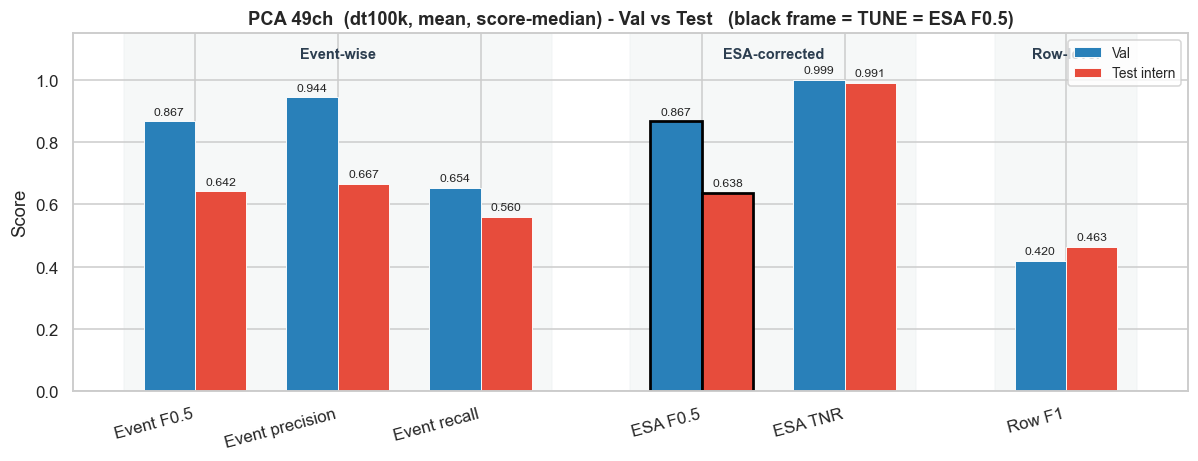

In [10]:
# Headline grouped bar chart - val vs test (nb21 style)
BAR_GROUPS = [
    ('Event-wise',    ['Event F0.5', 'Event precision', 'Event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['Row F1']),
]
LABEL_TO_KEY = {
    'Event F0.5'     : 'event F0.5 (raw)',
    'Event precision': 'event precision',
    'Event recall'   : 'event recall',
    'ESA F0.5'       : 'ESA F0.5 (Kaggle)',
    'ESA TNR'        : 'TNR (row spec)',
    'Row F1'         : 'row F1',
}
TUNE_LABEL = 'ESA F0.5'
_dt_lbl    = f'dt{int(DETREND_WIN/1000)}k' if DETREND_WIN else 'dt off'
_topk_lbl  = f'topK={TOPK}' if TOPK else 'mean'
MODEL_NAME = f'PCA {N_FEAT_SUB}ch  ({_dt_lbl}, {_topk_lbl}, score-{SCORE_DETREND_MD})'

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.36, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs = np.asarray(xs)
vals_val  = [m_val [LABEL_TO_KEY[l]] for l in xlabels]
vals_test = [m_test[LABEL_TO_KEY[l]] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8     if l == TUNE_LABEL else 0.6     for l in xlabels]

b1 = ax.bar(xs - w/2, vals_val,  w, label='Val',         color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
b2 = ax.bar(xs + w/2, vals_test, w, label='Test intern', color=ANOMALY_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo + xhi)/2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'{MODEL_NAME} - Val vs Test   (black frame = TUNE = {TUNE_LABEL})', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout(); plt.show()


## 8 - Timeline plots

`plot_timeline` shows the windowed MSE on the upper panel (with the threshold line and shaded
true-anomaly bands) and predicted vs true events on the lower panel (TP / FP, equal panel
heights). Use `log_y=True` so a single large spike doesn't squash everything else.

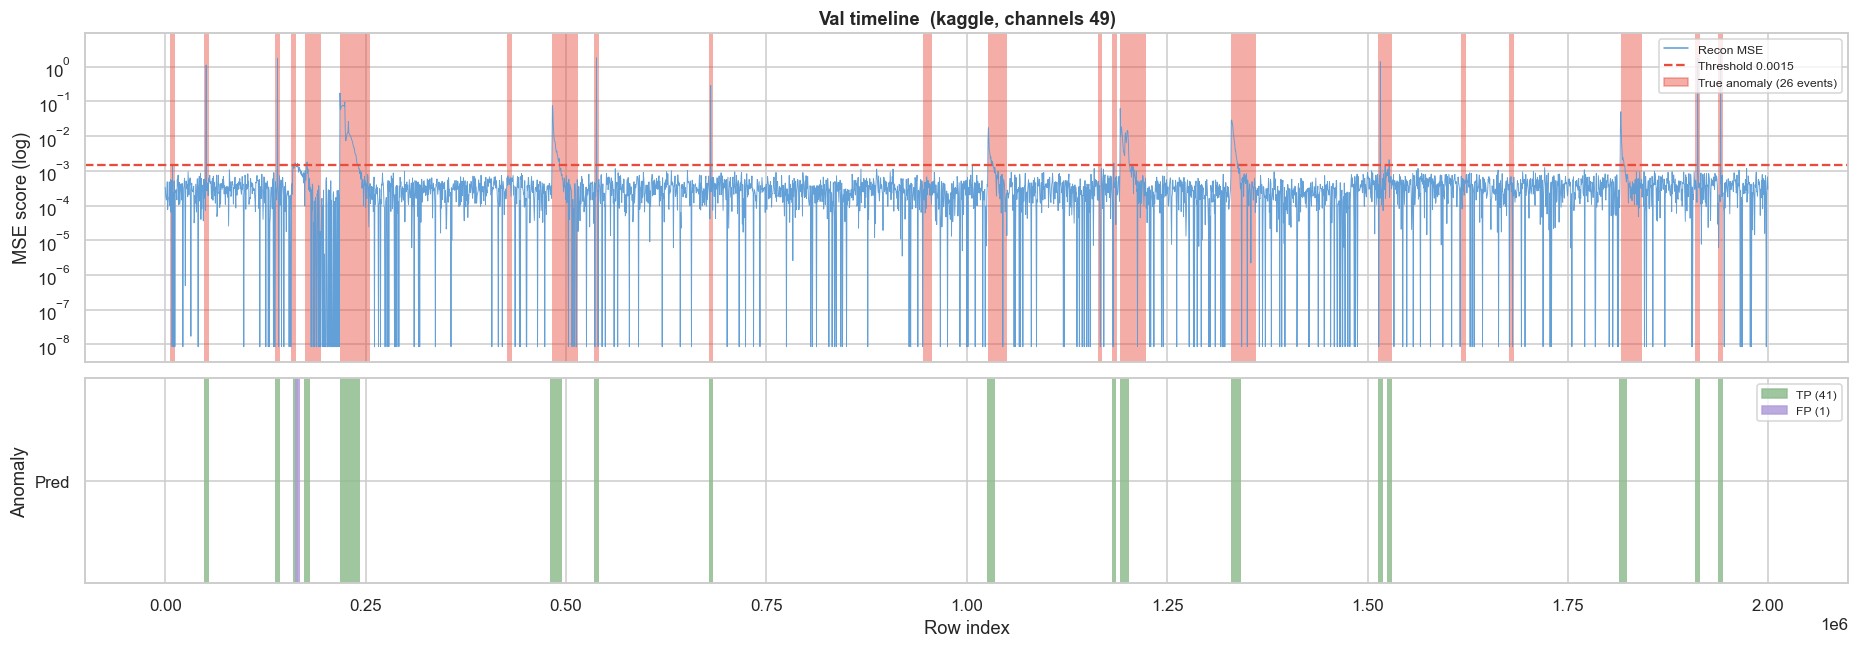

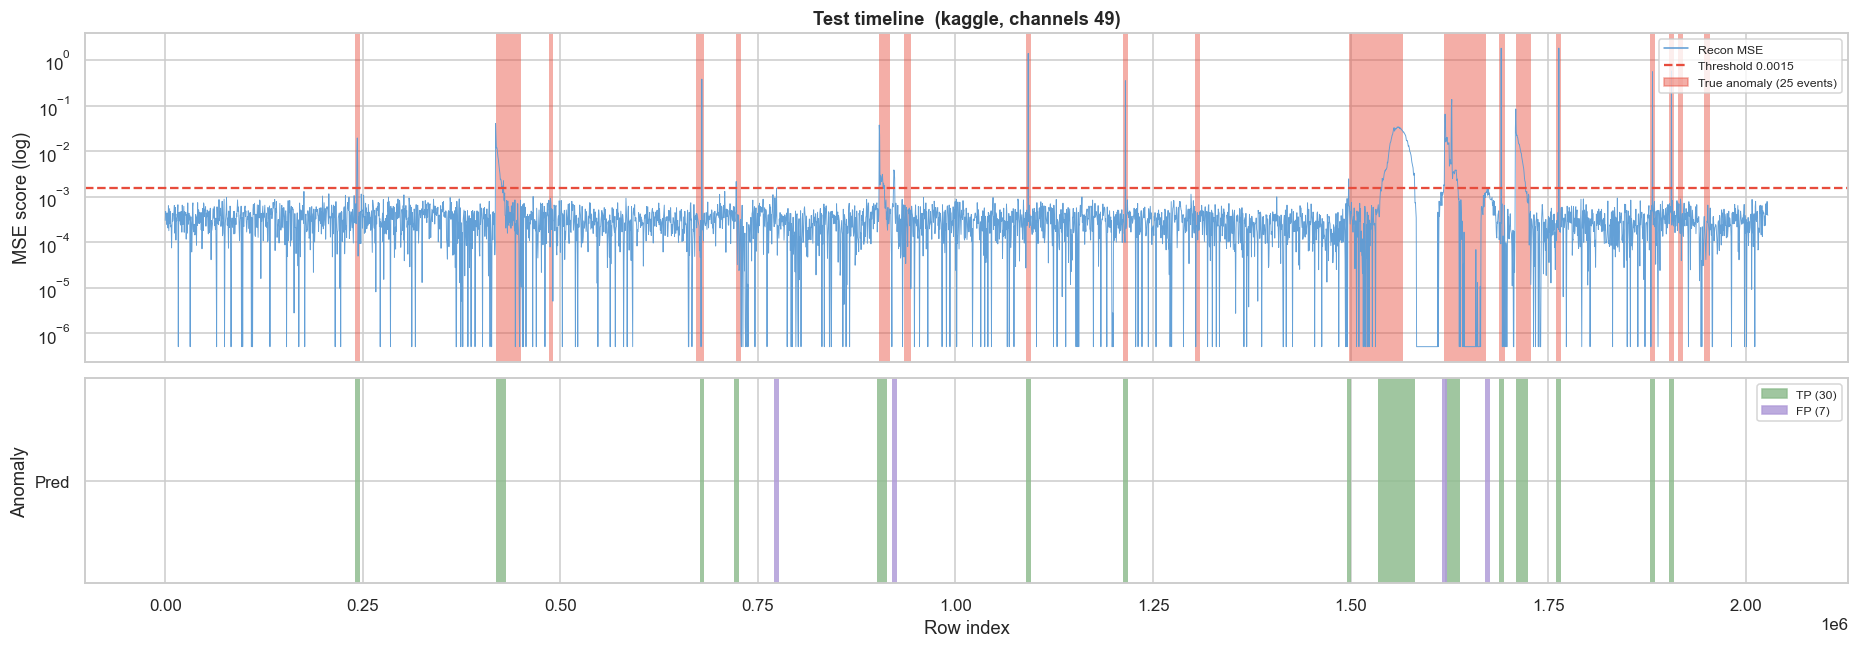

In [11]:
_ = plot_timeline(val_scores,  y_val,  threshold,
                  title=f'Val timeline  ({DATA_SOURCE}, channels {len(CH_INDICES)})',
                  log_y=True)
plt.show()

_ = plot_timeline(test_scores, y_test, threshold,
                  title=f'Test timeline  ({DATA_SOURCE}, channels {len(CH_INDICES)})',
                  log_y=True)
plt.show()


## 9 - Event analysis - detected vs missed

`plot_event_analysis` shows each true event as a horizontal bar (length on log scale,
green = detected, red = missed, hit-rate annotated) plus a length-bucket summary on the right.

Missed events:
  start     end  length
   9219    9587     369
 429365  429700     336
 947186  949024    1839
 952299  954134    1836
1165985 1166260     276
1522146 1522332     187
1522643 1523752    1110
1619693 1619971     279
1679098 1680347    1250


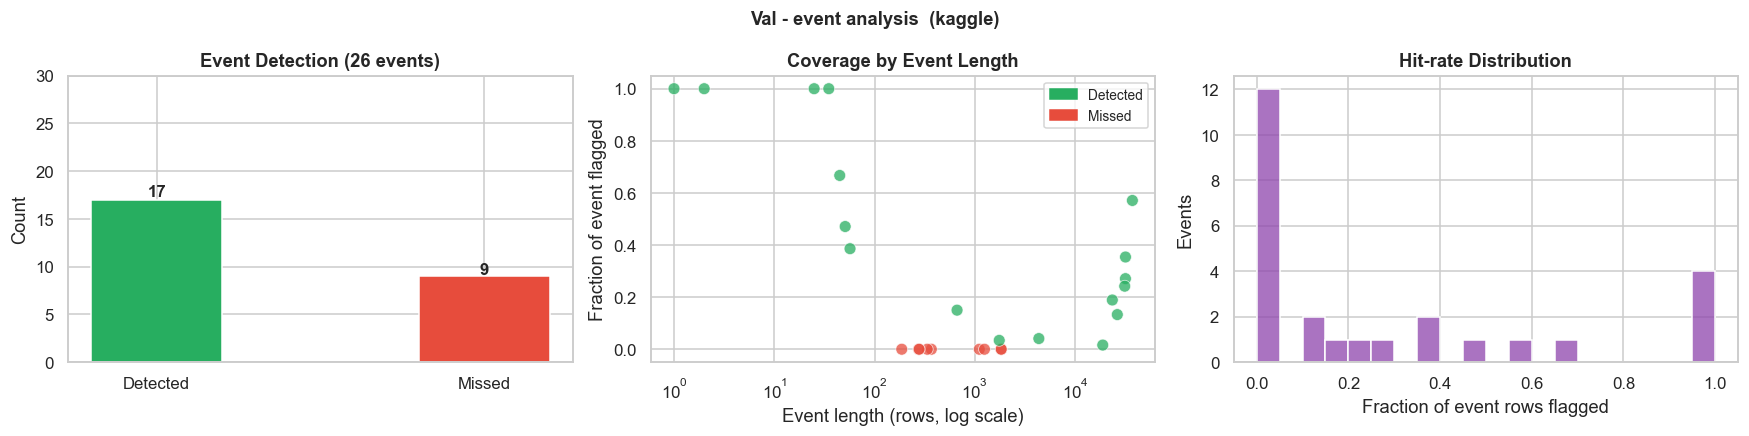

Missed events:
  start     end  length
 485619  490754    5136
 937585  937616      32
 938221  938247      27
 939737  939759      23
 940375  940404      30
1305587 1306297     711
1690836 1692821    1986
1916825 1917361     537
1949666 1949668       3
1949681 1949683       3
1949804 1954252    4449


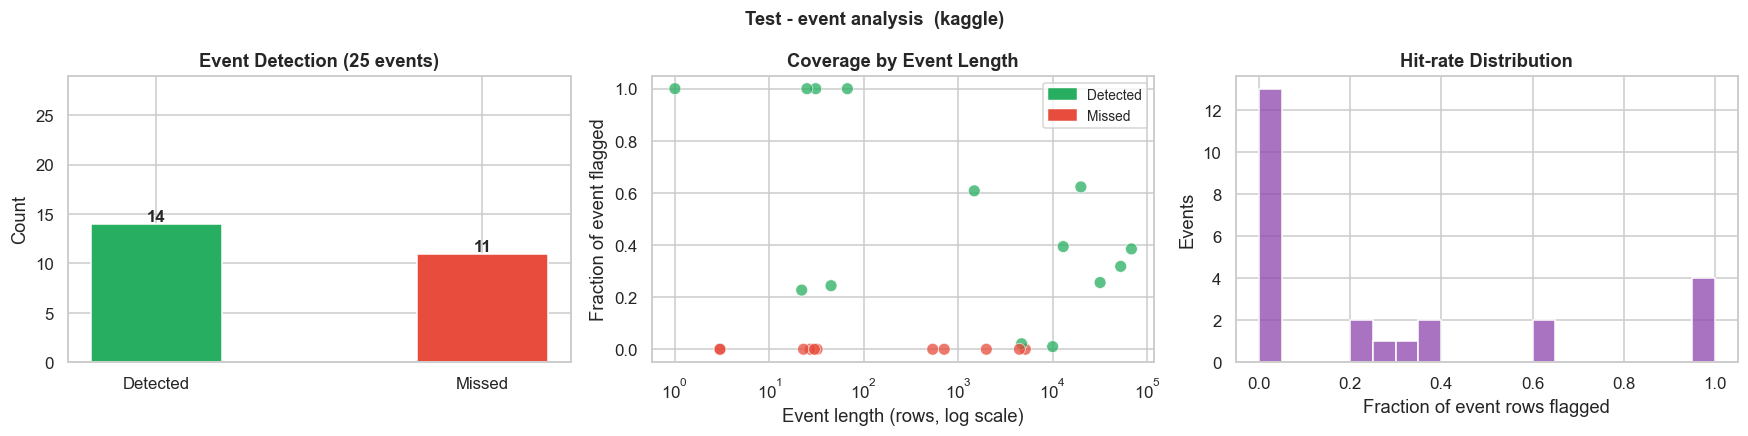

In [12]:
_ = plot_event_analysis(y_val,  m_val['_y_pred'],
                        title=f'Val - event analysis  ({DATA_SOURCE})')
plt.show()

_ = plot_event_analysis(y_test, m_test['_y_pred'],
                        title=f'Test - event analysis  ({DATA_SOURCE})')
plt.show()


## 10 - Save model & Kaggle submission

In [13]:
def _compact_ch_tag(names):
    """Compact filename tag for channel sets. Range -> 'ch41-46', otherwise 'NNch'."""
    nums = sorted(int(c.replace("channel_", "")) for c in names)
    if nums == list(range(nums[0], nums[-1] + 1)):
        return f"ch{nums[0]}-{nums[-1]}"
    return f"{len(nums)}ch"

# Save model
# MODELS_DIR.mkdir(exist_ok=True)
# ts  = time.strftime('%Y%m%d_%H%M%S')
# tag = f'{_compact_ch_tag(CH_NAMES)}_dt{int(DETREND_WIN/1000) if DETREND_WIN else 0}k_topK{TOPK}'
# model_path = MODELS_DIR / f'pca_nb11d_{tag}_{ts}.pkl'
# with open(model_path, 'wb') as f:
#     pickle.dump({'pca': pca, 'channels': CH_NAMES, 'ch_indices': CH_INDICES,
#                  'threshold': threshold, 'data_source': DATA_SOURCE,
#                  'detrend_win': DETREND_WIN, 'topk': TOPK}, f)
# print(f'Model saved → {model_path}')


In [14]:
# Save scores
# SCORES_DIR = PROCESSED_DIR / 'scores'
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
# np.save(SCORES_DIR / 'scores_val_pca_nb11d.npy',  val_scores)
# np.save(SCORES_DIR / 'scores_test_pca_nb11d.npy', test_scores)
# print(f'Scores saved to {SCORES_DIR}')

In [15]:
# ── Kaggle submission ───────────────────────────────────────────────────
# Only valid when DATA_SOURCE == 'kaggle' (test_scaled was loaded with the same channel slice)
# assert DATA_SOURCE == 'kaggle' and can_submit, 'Submission only enabled in DATA_SOURCE=kaggle mode'

# X_kaggle      = test_scaled.astype(np.float32, copy=False)
# kaggle_scores = score_windows(pca, X_kaggle, topk=TOPK)
# y_kaggle      = (kaggle_scores > threshold).astype(np.uint8)
# print(f'Kaggle scores range : [{kaggle_scores.min():.4f}, {kaggle_scores.max():.4f}]')
# print(f'positive rate       : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')

# submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_kaggle})
# sample_sub = pd.read_parquet('../data/raw/sample_submission.parquet')
# assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch vs sample_submission'

# ts  = time.strftime('%Y%m%d_%H%M%S')
# topk_tag = f'topK{TOPK}' if TOPK else 'mean'
# tag = f'{_compact_ch_tag(CH_NAMES)}_dt{int(DETREND_WIN/1000) if DETREND_WIN else 0}k_{topk_tag}'
# submission_path = SUBS_DIR / f'pca_nb11d_{tag}_{ts}.parquet'
# submission.to_parquet(submission_path, index=False)
# print(f'Submission saved → {submission_path}')
